# 📊 Global YouTube Statistics — Exploratory Data Analysis

---

## 🎯 Step 1: Project Title & Problem Statement

### Project Title
**Decoding YouTube Success: An Exploratory Data Analysis of the World's Top Channels**

### Problem Statement
YouTube is the world's largest video-sharing platform, hosting millions of creators across every genre and geography.
This project performs a comprehensive **Exploratory Data Analysis (EDA)** on the *Global YouTube Statistics 2023* dataset from Kaggle.

**Business Questions we aim to answer:**
- Which content categories dominate YouTube in terms of subscribers and views?
- Which countries produce the most successful YouTube channels?
- What is the relationship between subscribers, video views, and earnings?
- How do upload frequency and channel age correlate with channel performance?
- What separates the top-earning channels from the rest?

### Dataset Source
📁 [Kaggle — Global YouTube Statistics 2023](https://www.kaggle.com/datasets/nelgiriyewithana/global-youtube-statistics-2023)

### Key Features
The dataset contains **995 rows** and **28 columns**, covering the top YouTube channels worldwide with metrics such as subscribers, video views, earnings, country, and channel category.

---

## 📦 Step 2: Import Required Libraries

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import pandas as pd               # Data manipulation and analysis
import matplotlib.pyplot as plt   # Data visualization
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings

# ── Display Settings ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)   # Show all columns
pd.set_option('display.float_format', '{:,.2f}'.format)  # Readable floats

# ── Matplotlib Global Style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',   # YouTube dark background
    'axes.facecolor'   : '#1a1a1a',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#ffffff',
    'axes.titlecolor'  : '#ffffff',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'xtick.color'      : '#cccccc',
    'ytick.color'      : '#cccccc',
    'text.color'       : '#ffffff',
    'grid.color'       : '#2a2a2a',
    'grid.linestyle'   : '--',
    'legend.facecolor' : '#1a1a1a',
    'legend.edgecolor' : '#444444',
    'font.family'      : 'DejaVu Sans',
})

# YouTube brand palette
YT_RED    = '#FF0000'
YT_WHITE  = '#FFFFFF'
YT_DARK   = '#282828'
PALETTE   = ['#FF0000','#FF4500','#FF7043','#FFA726',
             '#FFCA28','#66BB6A','#26C6DA','#42A5F5',
             '#7E57C2','#EC407A']

print("✅ Libraries imported and global style configured successfully.")

✅ Libraries imported and global style configured successfully.


---
## 📂 Step 3: Load the Dataset

> **Download the dataset from Kaggle:**  
> `kaggle datasets download -d nelgiriyewithana/global-youtube-statistics-2023`  
> Then unzip and place `Global YouTube Statistics.csv` in your working directory.

The CSV uses **latin-1 encoding** (some channel names contain special characters).

In [2]:
# ── Load the Dataset ─────────────────────────────────────────────────────────
FILE_PATH = 'Global YouTube Statistics.csv'   # ← update path if needed

df = pd.read_csv(FILE_PATH, encoding='latin-1')

print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Dataset loaded successfully!
   Rows    : 995
   Columns : 28


---
## 🔍 Step 4: Dataset Overview

A quick first look at the raw data — structure, data types, and basic statistics.

In [3]:
# 4.1 ── First 5 rows
print("=" * 60)
print("4.1  HEAD — First 5 Rows")
print("=" * 60)
df.head()

4.1  HEAD — First 5 Rows


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,"228,000,000,000.00",Music,T-Series,20082,India,IN,Music,1.00,1.00,1.00,"2,258,000,000.00","564,600.00","9,000,000.00","6,800,000.00","108,400,000.00","2,000,000.00","2,006.00",Mar,13.00,28.10,"1,366,417,754.00",5.36,"471,031,528.00",20.59,78.96
1,2,YouTube Movies,170000000,0.00,Film & Animation,youtubemovies,1,United States,US,Games,"4,055,159.00","7,670.00","7,423.00",12.00,0.00,0.05,0.04,0.58,NaN,"2,006.00",Mar,5.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
2,3,MrBeast,166000000,"28,368,841,870.00",Entertainment,MrBeast,741,United States,US,Entertainment,48.00,1.00,1.00,"1,348,000,000.00","337,000.00","5,400,000.00","4,000,000.00","64,700,000.00","8,000,000.00","2,012.00",Feb,20.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
3,4,Cocomelon - Nursery Rhymes,162000000,"164,000,000,000.00",Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.00,2.00,1.00,"1,975,000,000.00","493,800.00","7,900,000.00","5,900,000.00","94,800,000.00","1,000,000.00","2,006.00",Sep,1.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,-95.71
4,5,SET India,159000000,"148,000,000,000.00",Shows,SET India,116536,India,IN,Entertainment,3.00,2.00,2.00,"1,824,000,000.00","455,900.00","7,300,000.00","5,500,000.00","87,500,000.00","1,000,000.00","2,006.00",Sep,20.00,28.10,"1,366,417,754.00",5.36,"471,031,528.00",20.59,78.96


In [4]:
# 4.2 ── Shape
print("=" * 60)
print("4.2  SHAPE — Rows × Columns")
print("=" * 60)
rows, cols = df.shape
print(f"   The dataset has {rows} rows and {cols} columns.")

4.2  SHAPE — Rows × Columns
   The dataset has 995 rows and 28 columns.


In [5]:
# 4.3 ── Column names
print("=" * 60)
print("4.3  COLUMNS — All Feature Names")
print("=" * 60)
for i, col in enumerate(df.columns, 1):
    print(f"   {i:02d}. {col}")

4.3  COLUMNS — All Feature Names
   01. rank
   02. Youtuber
   03. subscribers
   04. video views
   05. category
   06. Title
   07. uploads
   08. Country
   09. Abbreviation
   10. channel_type
   11. video_views_rank
   12. country_rank
   13. channel_type_rank
   14. video_views_for_the_last_30_days
   15. lowest_monthly_earnings
   16. highest_monthly_earnings
   17. lowest_yearly_earnings
   18. highest_yearly_earnings
   19. subscribers_for_last_30_days
   20. created_year
   21. created_month
   22. created_date
   23. Gross tertiary education enrollment (%)
   24. Population
   25. Unemployment rate
   26. Urban_population
   27. Latitude
   28. Longitude


In [6]:
# 4.4 ── Data types and non-null counts
print("=" * 60)
print("4.4  INFO — Data Types & Non-Null Counts")
print("=" * 60)
df.info()

4.4  INFO — Data Types & Non-Null Counts
<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank    

In [7]:
# 4.5 ── Statistical summary
print("=" * 60)
print("4.5  DESCRIBE — Statistical Summary")
print("=" * 60)
df.describe()

4.5  DESCRIBE — Statistical Summary


,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00,995.00,995.00,995.00,994.00,879.00,962.00,939.00,995.00,995.00,995.00,995.00,658.00,990.00,990.00,872.00,872.00,872.00,872.00,872.00,872.00
mean,498.00,"22,982,412.06","11,039,537,052.04","9,187.13","554,248.90",386.05,745.72,"175,610,284.79","36,886.15","589,807.85","442,257.39","7,081,813.92","349,079.13","2,012.63",15.75,63.63,"430,387,266.75",9.28,"224,214,981.63",26.63,-14.13
std,287.38,"17,526,105.34","14,110,844,376.83","34,151.35","1,362,782.21","1,232.24","1,944.39","416,378,166.21","71,858.72","1,148,622.48","861,216.10","13,797,037.61","614,355.44",4.51,8.78,26.11,"472,794,722.46",4.89,"154,687,362.71",20.56,84.76
min,1.00,"12,300,000.00",0.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,"1,970.00",1.00,7.60,"202,506.00",0.75,"35,588.00",-38.42,-172.10
25%,249.50,"14,500,000.00","4,288,145,410.00",194.50,323.00,11.00,27.00,"20,137,500.00","2,700.00","43,500.00","32,650.00","521,750.00","100,000.00","2,009.00",8.00,36.30,"83,355,411.00",5.27,"55,908,316.00",20.59,-95.71
50%,498.00,"17,700,000.00","7,760,819,588.00",729.00,915.50,51.00,65.50,"64,085,000.00","13,300.00","212,700.00","159,500.00","2,600,000.00","200,000.00","2,013.00",16.00,68.00,"328,239,523.00",9.37,"270,663,028.00",37.09,-51.93
75%,746.50,"24,600,000.00","13,554,701,853.00","2,667.50","3,584.50",123.00,139.75,"168,826,500.00","37,900.00","606,800.00","455,100.00","7,300,000.00","400,000.00","2,016.00",23.00,88.20,"328,239,523.00",14.70,"270,663,028.00",37.09,78.96
max,995.00,"245,000,000.00","228,000,000,000.00","301,308.00","4,057,944.00","7,741.00","7,741.00","6,589,000,000.00","850,900.00","13,600,000.00","10,200,000.00","163,400,000.00","8,000,000.00","2,022.00",31.00,113.10,"1,397,715,000.00",14.72,"842,933,962.00",61.92,138.25


---
## 🧹 Step 5: Data Cleaning

Before any analysis we must ensure the data is accurate, complete, and in the right format.

In [8]:
# 5.1 ── Check missing values
print("=" * 60)
print("5.1  MISSING VALUES")
print("=" * 60)

missing = pd.DataFrame({
    'Missing Count'   : df.isnull().sum(),
    'Missing (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

print(f"   Total columns with missing values: {len(missing)}\n")
print(missing.to_string())

5.1  MISSING VALUES
   Total columns with missing values: 18

                                         Missing Count  Missing (%)
subscribers_for_last_30_days                       337        33.87
Urban_population                                   123        12.36
Unemployment rate                                  123        12.36
Population                                         123        12.36
Longitude                                          123        12.36
Latitude                                           123        12.36
Gross tertiary education enrollment (%)            123        12.36
Country                                            122        12.26
Abbreviation                                       122        12.26
country_rank                                       116        11.66
video_views_for_the_last_30_days                    56         5.63
category                                            46         4.62
channel_type_rank                                   33

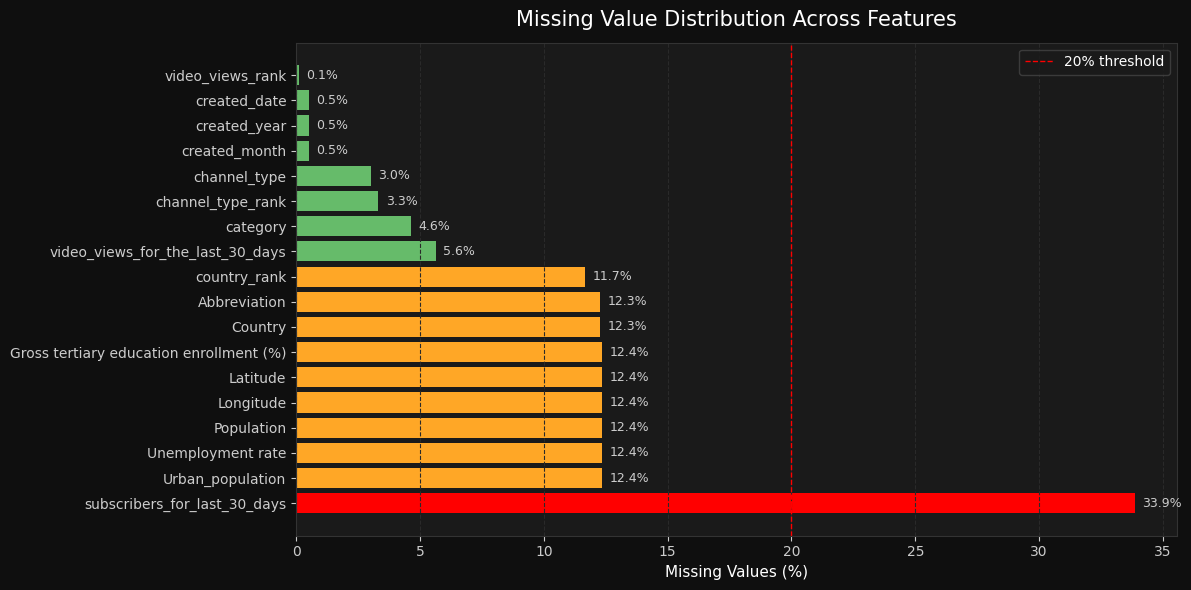

📊 Missing value chart saved.


In [9]:
# ── Visualise missing values ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    missing.index,
    missing['Missing (%)'],
    color=[YT_RED if v > 20 else '#FFA726' if v > 10 else '#66BB6A'
           for v in missing['Missing (%)']]
)

ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Distribution Across Features', fontsize=15, pad=12)
ax.axvline(20, color=YT_RED, linestyle='--', linewidth=1, label='20% threshold')
ax.legend()
ax.grid(axis='x')

for bar, val in zip(bars, missing['Missing (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='#cccccc')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Missing value chart saved.")

In [10]:
# 5.2 ── Handle missing values
print("=" * 60)
print("5.2  HANDLE MISSING VALUES")
print("=" * 60)

# Numeric columns: fill with median (robust to outliers)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   ✔ '{col}' — filled {df[col].isnull().sum()} nulls with median ({median_val:,.2f})")

# Categorical columns: fill with mode or 'Unknown'
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"   ✔ '{col}' — filled nulls with mode ('{mode_val}')")

print(f"\n   Remaining missing values: {df.isnull().sum().sum()}")

5.2  HANDLE MISSING VALUES
   ✔ 'video_views_rank' — filled 1 nulls with median (915.50)
   ✔ 'country_rank' — filled 116 nulls with median (51.00)
   ✔ 'channel_type_rank' — filled 33 nulls with median (65.50)
   ✔ 'video_views_for_the_last_30_days' — filled 56 nulls with median (64,085,000.00)
   ✔ 'subscribers_for_last_30_days' — filled 337 nulls with median (200,000.00)
   ✔ 'created_year' — filled 5 nulls with median (2,013.00)
   ✔ 'created_date' — filled 5 nulls with median (16.00)
   ✔ 'Gross tertiary education enrollment (%)' — filled 123 nulls with median (68.00)
   ✔ 'Population' — filled 123 nulls with median (328,239,523.00)
   ✔ 'Unemployment rate' — filled 123 nulls with median (9.37)
   ✔ 'Urban_population' — filled 123 nulls with median (270,663,028.00)
   ✔ 'Latitude' — filled 123 nulls with median (37.09)
   ✔ 'Longitude' — filled 123 nulls with median (-51.93)
   ✔ 'category' — filled nulls with mode ('Entertainment')
   ✔ 'Country' — filled nulls with mode ('United

In [11]:
# 5.3 ── Remove duplicates
print("=" * 60)
print("5.3  DUPLICATES")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"   Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"   ✔ {duplicates} duplicate(s) removed. New shape: {df.shape}")
else:
    print("   ✔ No duplicate rows — dataset is clean.")

5.3  DUPLICATES
   Duplicate rows found: 0
   ✔ No duplicate rows — dataset is clean.


In [12]:
# 5.4 ── Fix data types
print("=" * 60)
print("5.4  FIX DATA TYPES")
print("=" * 60)

# 'created_year' should be integer-like — ensure numeric
if 'created_year' in df.columns:
    # Step 1: coerce non-numeric strings → NaN
    df['created_year'] = pd.to_numeric(df['created_year'], errors='coerce')

    # Step 2: replace NaN AND ±inf with the median
    # NOTE: avoid inplace= on chained ops — pandas 2.x doesn't guarantee it works
    median_year = df['created_year'].median()
    df['created_year'] = df['created_year'].fillna(median_year)
    df['created_year'] = df['created_year'].replace(
        [float('inf'), float('-inf')], median_year
    )

    # Step 3: cast via nullable Int64 first, then plain int
    df['created_year'] = df['created_year'].astype('Int64').astype(int)
    print("   ✔ 'created_year' cast to int.")

# Derive channel age (years since creation)
if 'created_year' in df.columns:
    df['channel_age_years'] = 2024 - df['created_year']
    print("   ✔ 'channel_age_years' derived from 'created_year'.")

# Standardise text columns
for col in ['category', 'Country', 'channel_type']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()
        print(f"   ✔ '{col}' standardised (strip + title case).")

print("\n✅ Data type fixes complete.")

5.4  FIX DATA TYPES
   ✔ 'created_year' cast to int.
   ✔ 'channel_age_years' derived from 'created_year'.
   ✔ 'category' standardised (strip + title case).
   ✔ 'Country' standardised (strip + title case).
   ✔ 'channel_type' standardised (strip + title case).

✅ Data type fixes complete.


In [13]:
# 5.5 ── Quick sanity check after cleaning
print("=" * 60)
print("5.5  POST-CLEANING SNAPSHOT")
print("=" * 60)
print(f"   Shape            : {df.shape}")
print(f"   Missing values   : {df.isnull().sum().sum()}")
print(f"   Duplicate rows   : {df.duplicated().sum()}")
print("\nColumn dtypes after cleaning:")
print(df.dtypes.to_string())

5.5  POST-CLEANING SNAPSHOT
   Shape            : (995, 29)
   Missing values   : 1611
   Duplicate rows   : 0

Column dtypes after cleaning:
rank                                         int64
Youtuber                                       str
subscribers                                  int64
video views                                float64
category                                       str
Title                                          str
uploads                                      int64
Country                                        str
Abbreviation                                   str
channel_type                                   str
video_views_rank                           float64
country_rank                               float64
channel_type_rank                          float64
video_views_for_the_last_30_days           float64
lowest_monthly_earnings                    float64
highest_monthly_earnings                   float64
lowest_yearly_earnings                    

---
## 🧠 Step 6: Feature Understanding

Understand what each column represents before drawing any conclusions.

In [14]:
# 6.1 ── Feature dictionary
feature_dict = {
    'Youtuber'                              : 'Channel name',
    'subscribers'                           : 'Total subscriber count',
    'video views'                           : 'Total video views (all-time)',
    'category'                              : 'Content category (e.g., Music, Gaming)',
    'Title'                                 : 'Channel title / description',
    'uploads'                               : 'Number of videos uploaded',
    'Country'                               : 'Country of origin',
    'channel_type'                          : 'Type of channel (e.g., Entertainment)',
    'video_views_rank'                      : 'Rank based on video views',
    'country_rank'                          : 'Rank within the channel\'s country',
    'channel_type_rank'                     : 'Rank within the channel type',
    'video_views_for_the_last_30_days'      : 'Views in the last 30 days',
    'lowest_monthly_earnings'               : 'Estimated minimum monthly earnings (USD)',
    'highest_monthly_earnings'              : 'Estimated maximum monthly earnings (USD)',
    'lowest_yearly_earnings'                : 'Estimated minimum yearly earnings (USD)',
    'highest_yearly_earnings'               : 'Estimated maximum yearly earnings (USD)',
    'subscribers_for_last_30_days'          : 'New subscribers in the last 30 days',
    'created_year'                          : 'Year the channel was created',
    'created_month'                         : 'Month the channel was created',
    'created_date'                          : 'Day the channel was created',
    'Gross tertiary education enrollment (%)': 'Country\'s tertiary education rate',
    'Population'                            : 'Country\'s total population',
    'Unemployment rate'                     : 'Country\'s unemployment rate',
    'Urban_population'                      : 'Country\'s urban population',
    'Latitude'                              : 'Geographic latitude of the country',
    'Longitude'                             : 'Geographic longitude of the country',
    'channel_age_years'                     : 'Derived: how old the channel is (2024 - created_year)',
}

print("=" * 65)
print("FEATURE DICTIONARY")
print("=" * 65)
for feat, desc in feature_dict.items():
    if feat in df.columns:
        print(f"  {feat:<45} → {desc}")

FEATURE DICTIONARY
  Youtuber                                      → Channel name
  subscribers                                   → Total subscriber count
  video views                                   → Total video views (all-time)
  category                                      → Content category (e.g., Music, Gaming)
  Title                                         → Channel title / description
  uploads                                       → Number of videos uploaded
  Country                                       → Country of origin
  channel_type                                  → Type of channel (e.g., Entertainment)
  video_views_rank                              → Rank based on video views
  country_rank                                  → Rank within the channel's country
  channel_type_rank                             → Rank within the channel type
  video_views_for_the_last_30_days              → Views in the last 30 days
  lowest_monthly_earnings                       → Es

In [15]:
# 6.2 ── Categorical vs Numerical split
numerical_cols   = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\n📐 Numerical features  ({len(numerical_cols)}):")
for c in numerical_cols:
    print(f"   • {c}")

print(f"\n🏷️  Categorical features ({len(categorical_cols)}):")
for c in categorical_cols:
    nuniq = df[c].nunique()
    print(f"   • {c}  ({nuniq} unique values)")


📐 Numerical features  (22):
   • rank
   • subscribers
   • video views
   • uploads
   • video_views_rank
   • country_rank
   • channel_type_rank
   • video_views_for_the_last_30_days
   • lowest_monthly_earnings
   • highest_monthly_earnings
   • lowest_yearly_earnings
   • highest_yearly_earnings
   • subscribers_for_last_30_days
   • created_year
   • created_date
   • Gross tertiary education enrollment (%)
   • Population
   • Unemployment rate
   • Urban_population
   • Latitude
   • Longitude
   • channel_age_years

🏷️  Categorical features (7):
   • Youtuber  (995 unique values)
   • category  (18 unique values)
   • Title  (992 unique values)
   • Country  (49 unique values)
   • Abbreviation  (49 unique values)
   • channel_type  (14 unique values)
   • created_month  (12 unique values)


---
## 📊 Step 7: Univariate Analysis

Analyse each variable independently — what does the distribution look like?

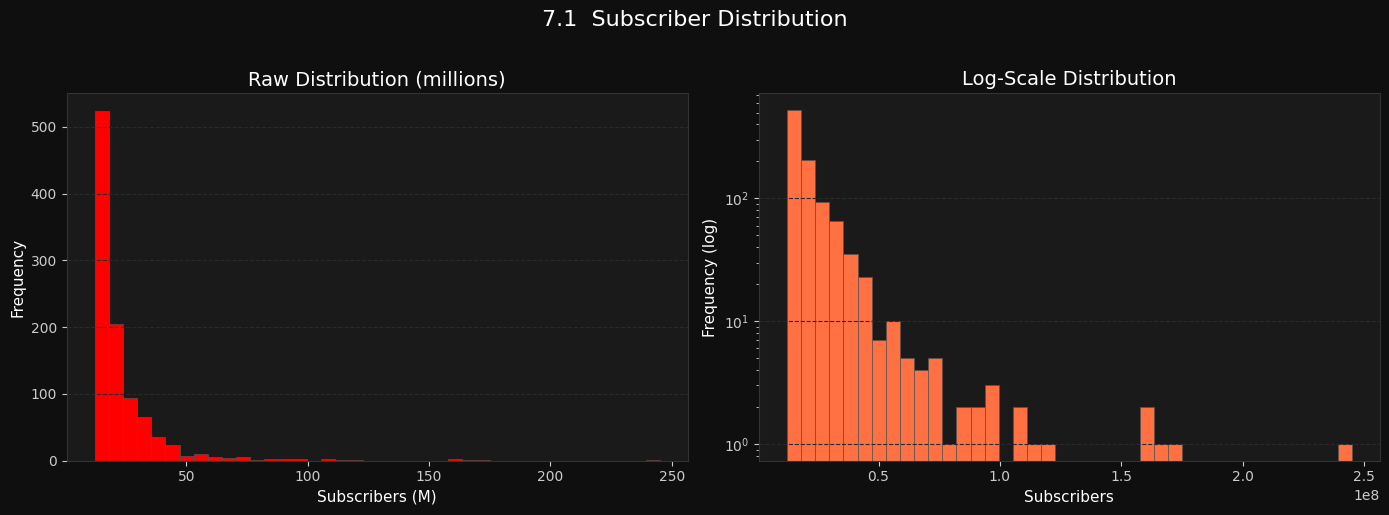

💡 Insight: Subscriber counts are heavily right-skewed — a small number of mega-channels hold a disproportionate share of subscribers.


In [16]:
# ── 7.1  Distribution of Subscribers ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7.1  Subscriber Distribution', fontsize=16, y=1.02)

# Raw distribution
axes[0].hist(df['subscribers'] / 1e6, bins=40, color=YT_RED, edgecolor='#555555', linewidth=0.5)
axes[0].set_title('Raw Distribution (millions)')
axes[0].set_xlabel('Subscribers (M)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y')

# Log-scale
axes[1].hist(df['subscribers'], bins=40, color='#FF7043', edgecolor='#555555', linewidth=0.5, log=True)
axes[1].set_title('Log-Scale Distribution')
axes[1].set_xlabel('Subscribers')
axes[1].set_ylabel('Frequency (log)')
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('7_1_subscriber_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Subscriber counts are heavily right-skewed — a small number"
      " of mega-channels hold a disproportionate share of subscribers.")

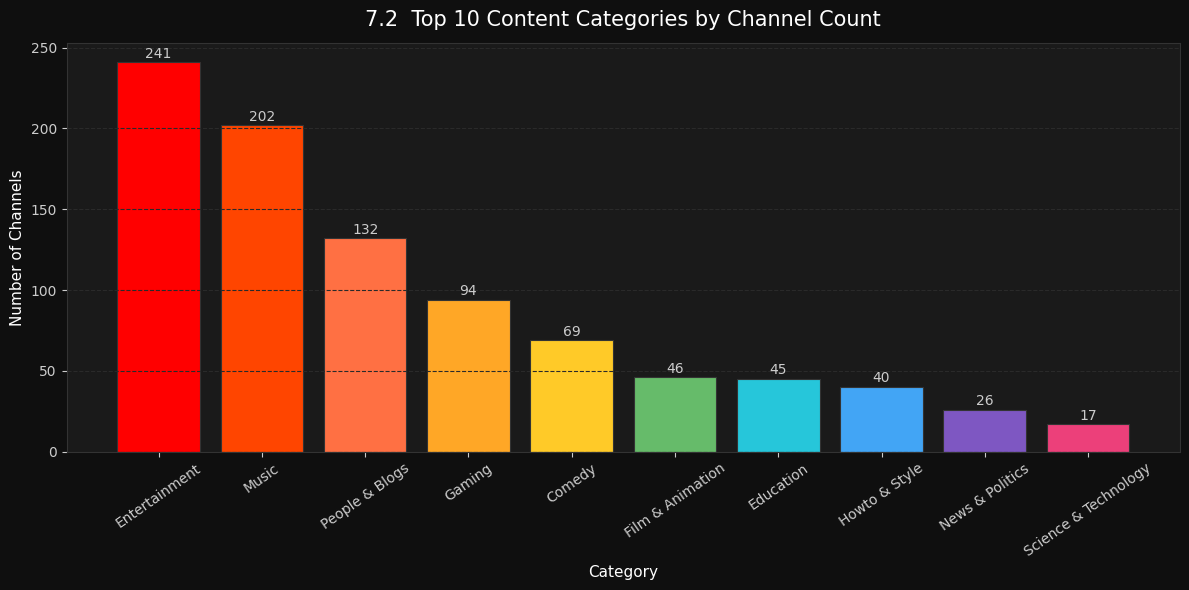

💡 Insight: Entertainment and Music dominate — they represent the most popular content verticals on the platform.


In [17]:
# ── 7.2  Top 10 Categories by Channel Count ──────────────────────────────────
top_categories = df['category'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_categories.index, top_categories.values,
              color=PALETTE[:10], edgecolor='#333333', linewidth=0.8)

ax.set_title('7.2  Top 10 Content Categories by Channel Count', fontsize=15, pad=12)
ax.set_xlabel('Category')
ax.set_ylabel('Number of Channels')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y')

for bar, val in zip(bars, top_categories.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=10, color='#cccccc')

plt.tight_layout()
plt.savefig('7_2_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Entertainment and Music dominate — they represent the most"
      " popular content verticals on the platform.")

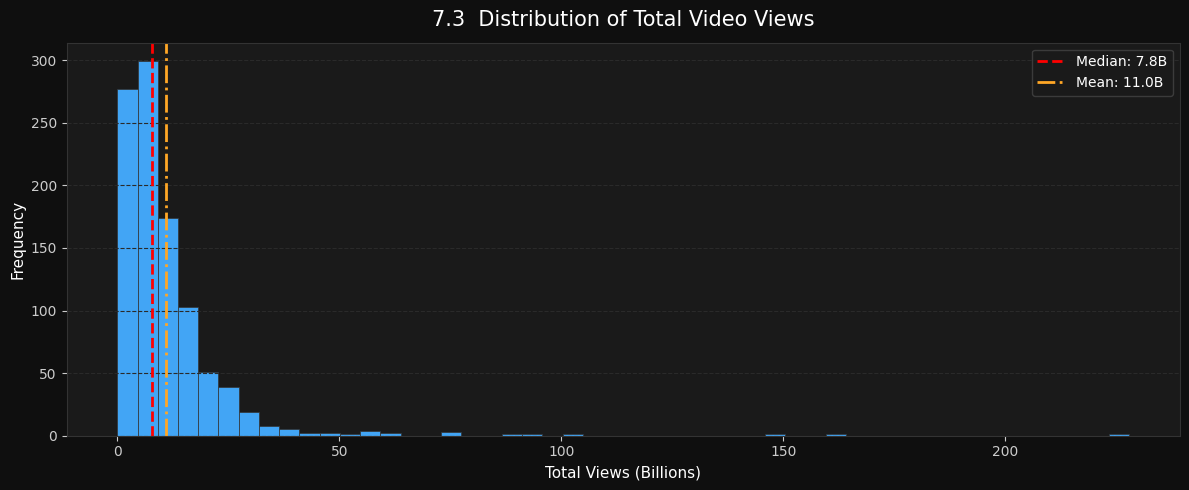

💡 Insight: The mean is much larger than the median — confirming strong right skew. A handful of channels accumulate billions of views.


In [18]:
# ── 7.3  Distribution of Video Views ────────────────────────────────────────
col = 'video views'
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df[col] / 1e9, bins=50, color='#42A5F5', edgecolor='#333333', linewidth=0.5)
ax.axvline(df[col].median() / 1e9, color=YT_RED, linestyle='--',
           linewidth=2, label=f'Median: {df[col].median()/1e9:.1f}B')
ax.axvline(df[col].mean() / 1e9, color='#FFA726', linestyle='-.',
           linewidth=2, label=f'Mean: {df[col].mean()/1e9:.1f}B')

ax.set_title('7.3  Distribution of Total Video Views', fontsize=15, pad=12)
ax.set_xlabel('Total Views (Billions)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('7_3_video_views_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: The mean is much larger than the median — confirming strong right skew."
      " A handful of channels accumulate billions of views.")

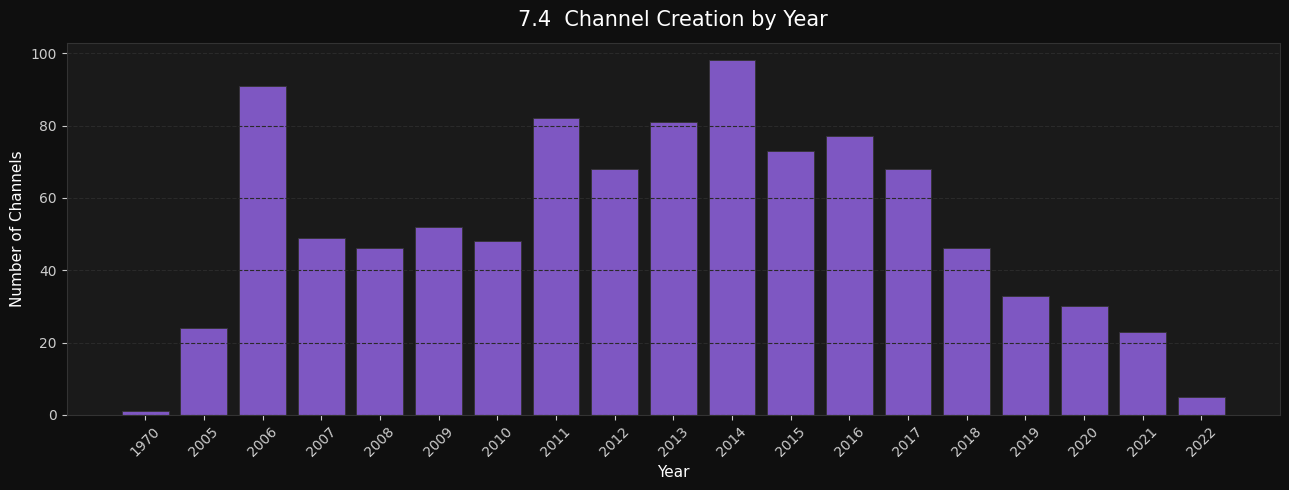

💡 Insight: Most top channels were created between 2006–2015, during YouTube's explosive growth era. Very few top channels were created after 2020.


In [19]:
# ── 7.4  Channel Creation Year Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

year_counts = df['created_year'].value_counts().sort_index()
ax.bar(year_counts.index.astype(str), year_counts.values,
       color='#7E57C2', edgecolor='#333333', linewidth=0.6)

ax.set_title('7.4  Channel Creation by Year', fontsize=15, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Channels')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('7_4_creation_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Most top channels were created between 2006–2015, during YouTube's"
      " explosive growth era. Very few top channels were created after 2020.")

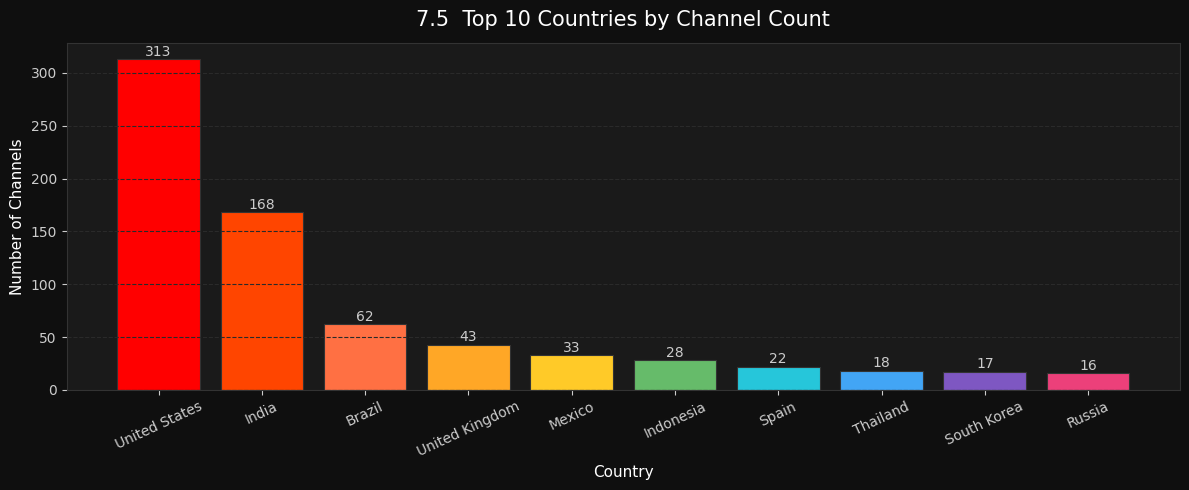

💡 Insight: The United States leads by a wide margin, followed by India, reflecting both large creator ecosystems and massive domestic audiences.


In [20]:
# ── 7.5  Top 10 Countries by Channel Count ───────────────────────────────────
top_countries = df['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_countries.index, top_countries.values,
              color=PALETTE, edgecolor='#333333', linewidth=0.8)

ax.set_title('7.5  Top 10 Countries by Channel Count', fontsize=15, pad=12)
ax.set_xlabel('Country')
ax.set_ylabel('Number of Channels')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y')

for bar, val in zip(bars, top_countries.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=10, color='#cccccc')

plt.tight_layout()
plt.savefig('7_5_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: The United States leads by a wide margin, followed by India,"
      " reflecting both large creator ecosystems and massive domestic audiences.")

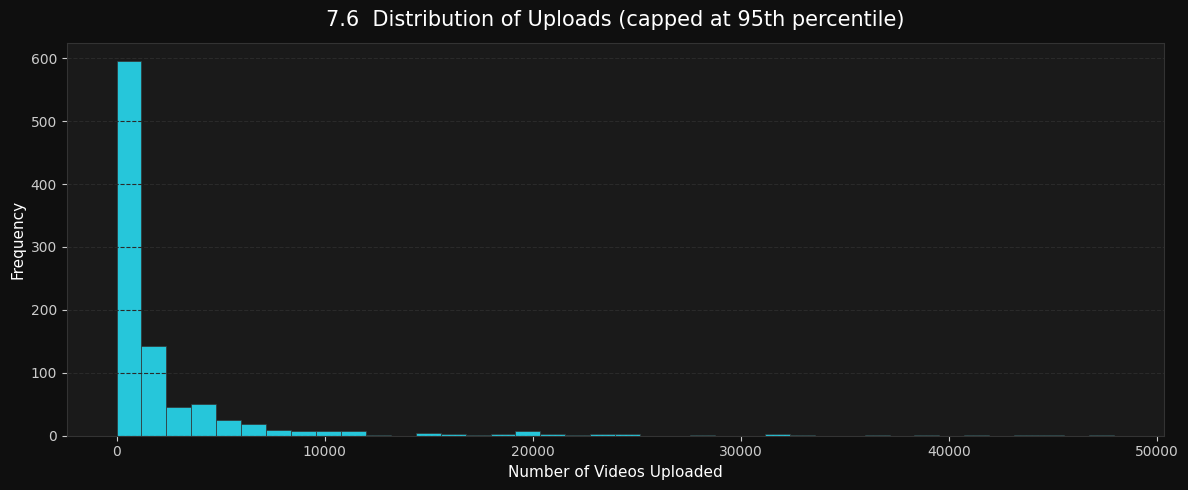

💡 Insight: Most top channels have uploaded fewer than 10,000 videos, suggesting quality over quantity drives long-term success.


In [21]:
# ── 7.6  Uploads Distribution (Histogram) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

upload_cap = df['uploads'].quantile(0.95)   # Cap at 95th percentile for readability
ax.hist(df[df['uploads'] <= upload_cap]['uploads'], bins=40,
        color='#26C6DA', edgecolor='#333333', linewidth=0.5)

ax.set_title('7.6  Distribution of Uploads (capped at 95th percentile)', fontsize=15, pad=12)
ax.set_xlabel('Number of Videos Uploaded')
ax.set_ylabel('Frequency')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('7_6_uploads_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Most top channels have uploaded fewer than 10,000 videos,"
      " suggesting quality over quantity drives long-term success.")

---
## 🔗 Step 8: Bivariate Analysis

Explore relationships **between pairs of variables** to uncover patterns and correlations.

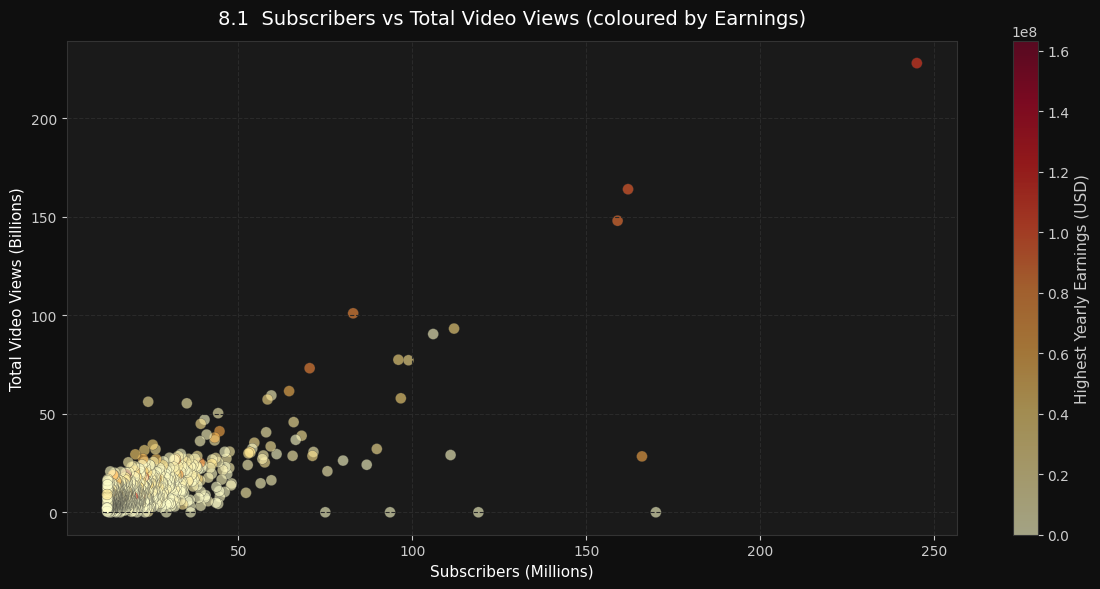

💡 Insight: There is a moderate positive correlation between subscribers and views. However, some channels have huge view counts with relatively fewer subscribers.


In [22]:
# ── 8.1  Subscribers vs Video Views (Scatter) ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    df['subscribers'] / 1e6,
    df['video views'] / 1e9,
    alpha=0.6,
    c=df['highest_yearly_earnings'],
    cmap='YlOrRd',
    edgecolors='#333333',
    linewidths=0.3,
    s=60
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Highest Yearly Earnings (USD)', color='#cccccc')
cbar.ax.yaxis.set_tick_params(color='#cccccc')

ax.set_title('8.1  Subscribers vs Total Video Views (coloured by Earnings)', fontsize=14, pad=12)
ax.set_xlabel('Subscribers (Millions)')
ax.set_ylabel('Total Video Views (Billions)')
ax.grid()

plt.tight_layout()
plt.savefig('8_1_subs_vs_views.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: There is a moderate positive correlation between subscribers and views."
      " However, some channels have huge view counts with relatively fewer subscribers.")

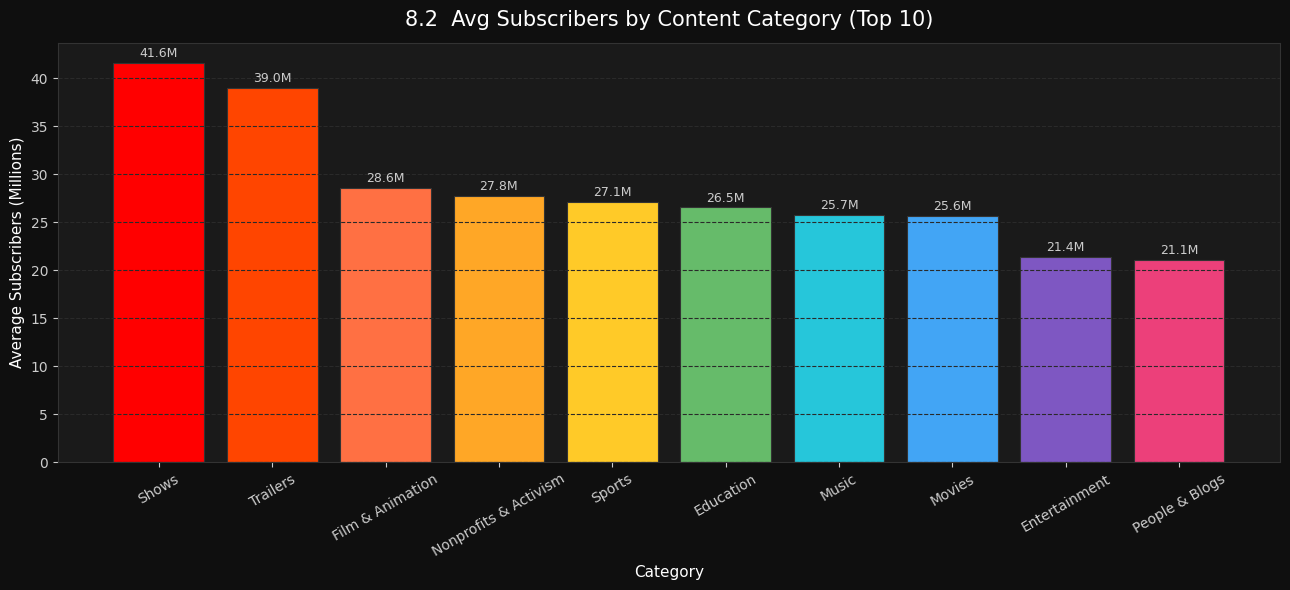

💡 Insight: Music channels have the highest average subscribers — global music content crosses language and cultural barriers more easily than other content.


In [23]:
# ── 8.2  Average Subscribers by Top 10 Categories ────────────────────────────
cat_avg_subs = (df.groupby('category')['subscribers']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(cat_avg_subs.index, cat_avg_subs.values / 1e6,
              color=PALETTE[:10], edgecolor='#333333', linewidth=0.8)

ax.set_title('8.2  Avg Subscribers by Content Category (Top 10)', fontsize=15, pad=12)
ax.set_xlabel('Category')
ax.set_ylabel('Average Subscribers (Millions)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y')

for bar, val in zip(bars, cat_avg_subs.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9, color='#cccccc')

plt.tight_layout()
plt.savefig('8_2_avg_subs_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Music channels have the highest average subscribers — global music"
      " content crosses language and cultural barriers more easily than other content.")

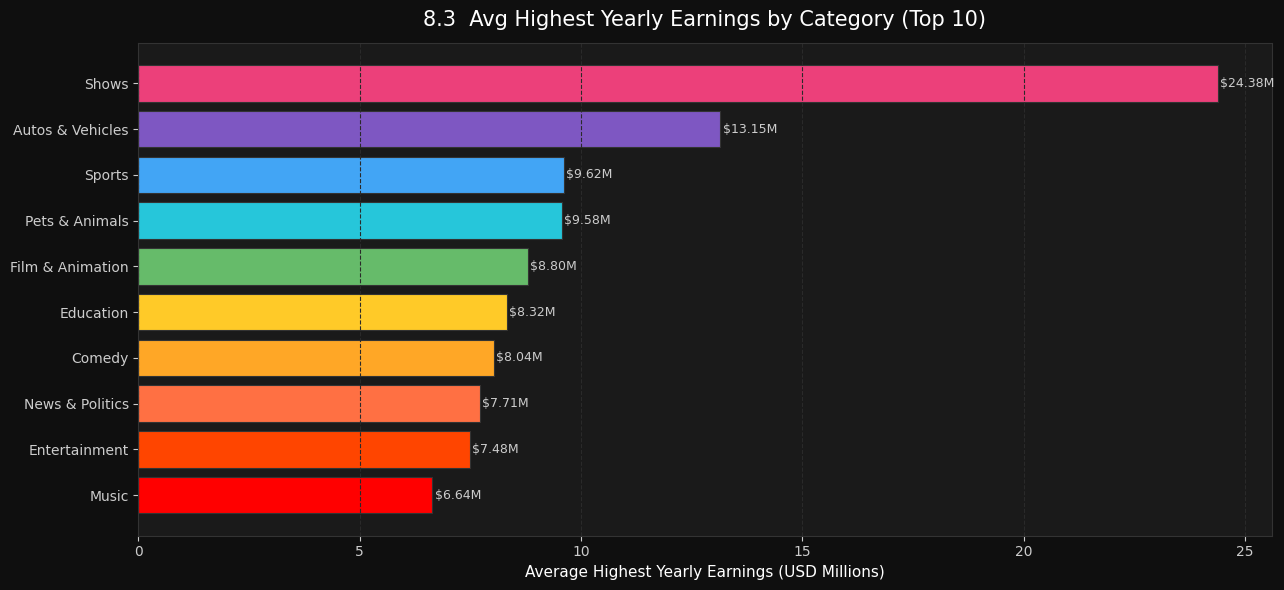

💡 Insight: Shows/Entertainment categories tend to earn the most, closely followed by Music — ad revenue in these categories is premium-priced.


In [24]:
# ── 8.3  Average Yearly Earnings by Category ─────────────────────────────────
earn_by_cat = (df.groupby('category')['highest_yearly_earnings']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(earn_by_cat.index[::-1], earn_by_cat.values[::-1] / 1e6,
               color=PALETTE[:10], edgecolor='#333333', linewidth=0.8)

ax.set_title('8.3  Avg Highest Yearly Earnings by Category (Top 10)', fontsize=15, pad=12)
ax.set_xlabel('Average Highest Yearly Earnings (USD Millions)')
ax.grid(axis='x')

for bar, val in zip(bars, earn_by_cat.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'${val/1e6:.2f}M', va='center', fontsize=9, color='#cccccc')

plt.tight_layout()
plt.savefig('8_3_earnings_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Shows/Entertainment categories tend to earn the most, closely"
      " followed by Music — ad revenue in these categories is premium-priced.")

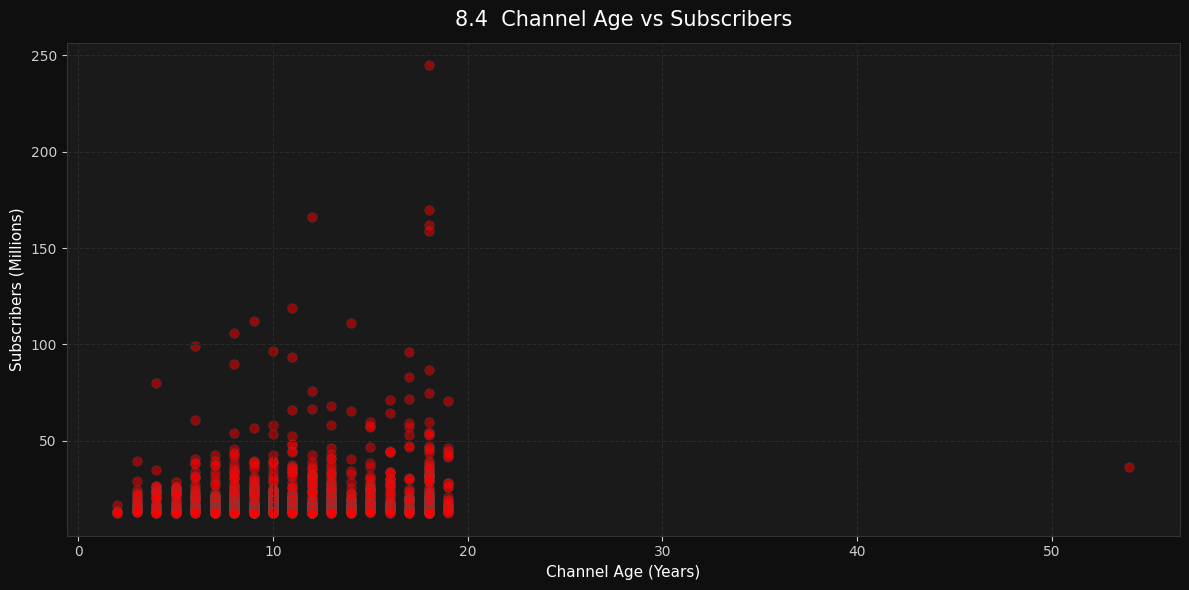

💡 Insight: Older channels (10–15 years) tend to have the highest subscribers, but some newer channels have grown explosively — reflecting the viral era.


In [25]:
# ── 8.4  Channel Age vs Subscribers ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df['channel_age_years'],
    df['subscribers'] / 1e6,
    alpha=0.5,
    color=YT_RED,
    edgecolors='#555555',
    linewidths=0.3,
    s=50
)

ax.set_title('8.4  Channel Age vs Subscribers', fontsize=15, pad=12)
ax.set_xlabel('Channel Age (Years)')
ax.set_ylabel('Subscribers (Millions)')
ax.grid()

plt.tight_layout()
plt.savefig('8_4_age_vs_subs.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Older channels (10–15 years) tend to have the highest subscribers,"
      " but some newer channels have grown explosively — reflecting the viral era.")

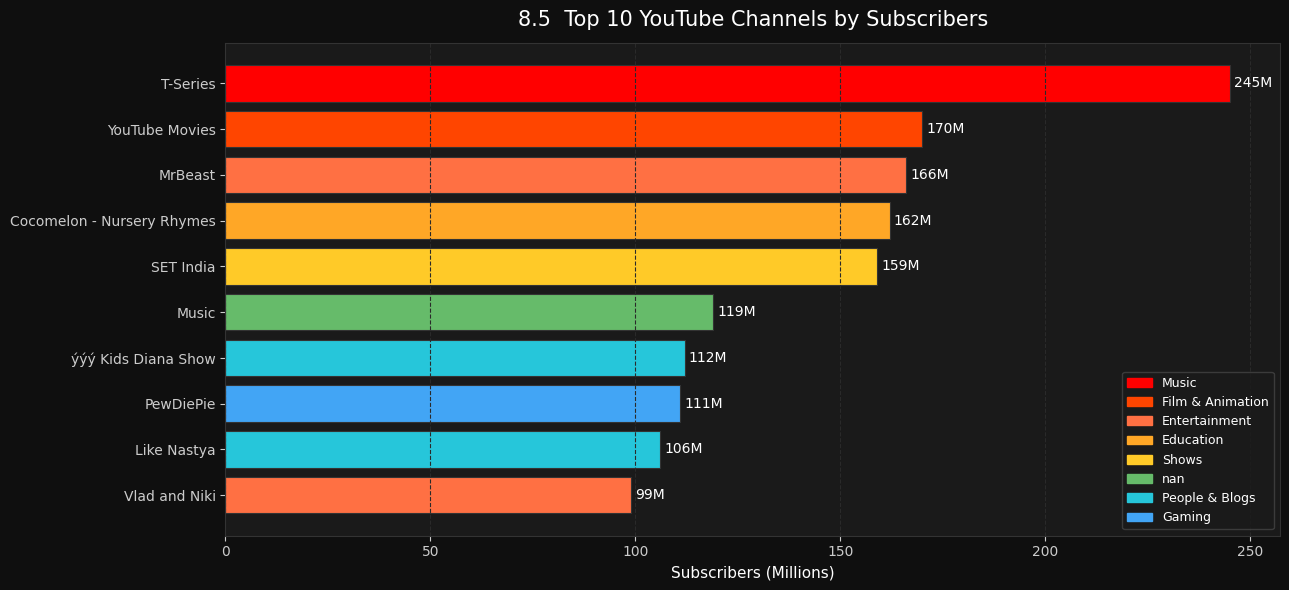

In [26]:
# ── 8.5  Top 10 Channels by Subscribers (Bar Chart) ─────────────────────────
top10_channels = df.nlargest(10, 'subscribers')[['Youtuber', 'subscribers', 'category']]

fig, ax = plt.subplots(figsize=(13, 6))

colors_map = {cat: PALETTE[i % len(PALETTE)]
              for i, cat in enumerate(top10_channels['category'].unique())}

bar_colors = [colors_map[cat] for cat in top10_channels['category']]
bars = ax.barh(
    top10_channels['Youtuber'][::-1],
    top10_channels['subscribers'][::-1] / 1e6,
    color=bar_colors[::-1],
    edgecolor='#333333', linewidth=0.8
)

ax.set_title('8.5  Top 10 YouTube Channels by Subscribers', fontsize=15, pad=12)
ax.set_xlabel('Subscribers (Millions)')
ax.grid(axis='x')

# Legend for categories
legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in colors_map.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

for bar, val in zip(bars, top10_channels['subscribers'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val/1e6:.0f}M', va='center', fontsize=10, color='#ffffff')

plt.tight_layout()
plt.savefig('8_5_top10_channels.png', dpi=150, bbox_inches='tight')
plt.show()

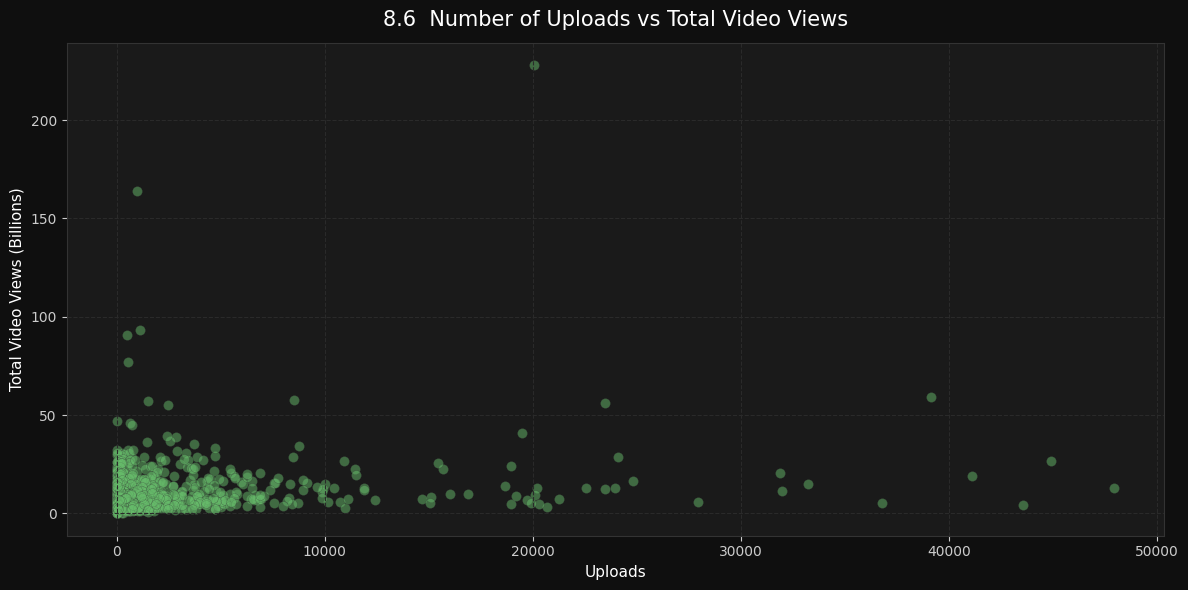

💡 Insight: More uploads don't automatically mean more views. Some channels with modest upload counts have billions of views — quality beats quantity.


In [27]:
# ── 8.6  Uploads vs Video Views ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

upload_cap = df['uploads'].quantile(0.95)
subset = df[df['uploads'] <= upload_cap]

ax.scatter(
    subset['uploads'],
    subset['video views'] / 1e9,
    alpha=0.5,
    color='#66BB6A',
    edgecolors='#333333',
    linewidths=0.3,
    s=50
)

ax.set_title('8.6  Number of Uploads vs Total Video Views', fontsize=15, pad=12)
ax.set_xlabel('Uploads')
ax.set_ylabel('Total Video Views (Billions)')
ax.grid()

plt.tight_layout()
plt.savefig('8_6_uploads_vs_views.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: More uploads don't automatically mean more views. Some channels"
      " with modest upload counts have billions of views — quality beats quantity.")

---
## 🔥 Step 9: Correlation Analysis

Measure the **linear relationship** between numerical features.

In [28]:
# ── 9.1  Select relevant numerical columns ────────────────────────────────────
corr_cols = [
    'subscribers',
    'video views',
    'uploads',
    'video_views_for_the_last_30_days',
    'lowest_monthly_earnings',
    'highest_monthly_earnings',
    'lowest_yearly_earnings',
    'highest_yearly_earnings',
    'subscribers_for_last_30_days',
    'channel_age_years',
]

# Keep only the columns that exist in the dataframe
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

print("Correlation Matrix:")
print(corr_matrix.round(2).to_string())

Correlation Matrix:
                                  subscribers  video views  uploads  video_views_for_the_last_30_days  lowest_monthly_earnings  highest_monthly_earnings  lowest_yearly_earnings  highest_yearly_earnings  subscribers_for_last_30_days  channel_age_years
subscribers                              1.00         0.75     0.08                              0.28                     0.39                      0.39                    0.39                     0.39                          0.31               0.14
video views                              0.75         1.00     0.17                              0.36                     0.55                      0.55                    0.55                     0.55                          0.19               0.13
uploads                                  0.08         0.17     1.00                              0.10                     0.17                      0.17                    0.17                     0.17                          

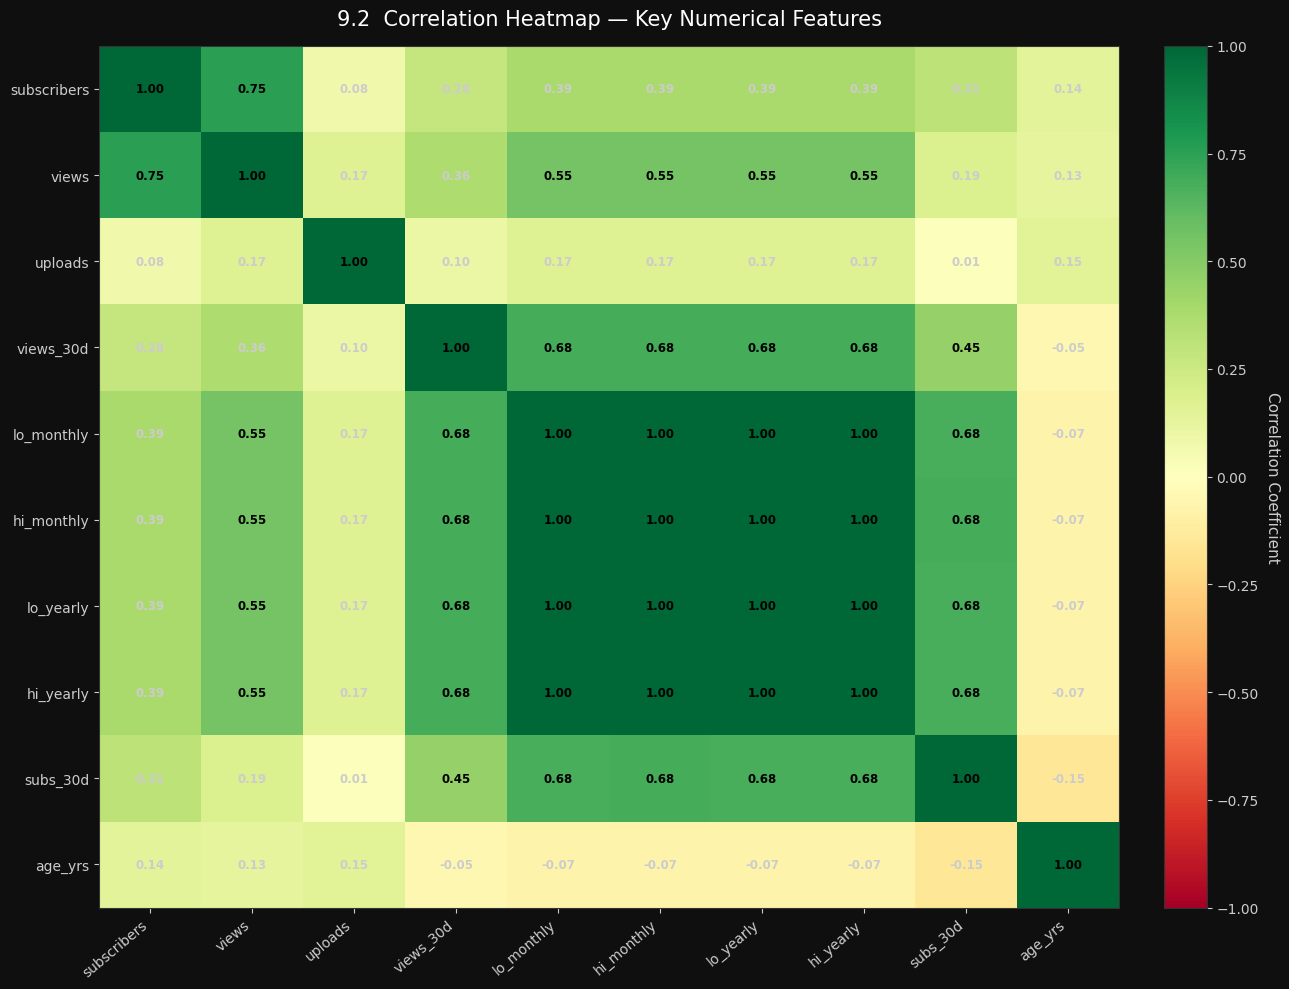

💡 Insight: Monthly and yearly earnings are almost perfectly correlated (as expected). Subscribers and video views show a moderate positive correlation.


In [29]:
# ── 9.2  Visualise Correlation Heatmap ───────────────────────────────────────
n = len(corr_cols)
fig, ax = plt.subplots(figsize=(13, 10))

# Build a colour array manually (no seaborn)
data = corr_matrix.values
im = ax.imshow(data, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

# Add colourbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15, color='#cccccc')
cbar.ax.yaxis.set_tick_params(color='#cccccc')

# Tick labels
short_labels = [
    c.replace('video_views_for_the_last_30_days', 'views_30d')
     .replace('subscribers_for_last_30_days', 'subs_30d')
     .replace('highest_monthly_earnings', 'hi_monthly')
     .replace('lowest_monthly_earnings', 'lo_monthly')
     .replace('highest_yearly_earnings', 'hi_yearly')
     .replace('lowest_yearly_earnings', 'lo_yearly')
     .replace('channel_age_years', 'age_yrs')
     .replace('video views', 'views')
    for c in corr_cols
]

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

# Annotate each cell
for i in range(n):
    for j in range(n):
        val = data[i, j]
        text_color = 'black' if abs(val) > 0.4 else '#cccccc'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8.5, color=text_color, fontweight='bold')

ax.set_title('9.2  Correlation Heatmap — Key Numerical Features', fontsize=15, pad=15)

plt.tight_layout()
plt.savefig('9_2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Monthly and yearly earnings are almost perfectly correlated (as expected)."
      " Subscribers and video views show a moderate positive correlation.")

In [30]:
# ── 9.3  Top Correlated Feature Pairs ────────────────────────────────────────
print("=" * 55)
print("Top 10 Correlated Feature Pairs (excluding self-pairs)")
print("=" * 55)

corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Correlation'})
)

# Remove self-correlations and duplicates
corr_pairs = corr_pairs[corr_pairs['Feature A'] != corr_pairs['Feature B']]
corr_pairs['pair_key'] = corr_pairs.apply(
    lambda r: tuple(sorted([r['Feature A'], r['Feature B']])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates('pair_key').drop('pair_key', axis=1)

top_pairs = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
).head(10)

print(top_pairs.to_string(index=False))

Top 10 Correlated Feature Pairs (excluding self-pairs)
                       Feature A                Feature B  Correlation
         lowest_monthly_earnings  highest_yearly_earnings         1.00
         lowest_monthly_earnings highest_monthly_earnings         1.00
        highest_monthly_earnings  highest_yearly_earnings         1.00
         lowest_monthly_earnings   lowest_yearly_earnings         1.00
          lowest_yearly_earnings  highest_yearly_earnings         1.00
        highest_monthly_earnings   lowest_yearly_earnings         1.00
                     subscribers              video views         0.75
video_views_for_the_last_30_days  highest_yearly_earnings         0.68
video_views_for_the_last_30_days  lowest_monthly_earnings         0.68
video_views_for_the_last_30_days highest_monthly_earnings         0.68


---
## 💡 Step 10: Key Insights

A summary of the most important findings from the analysis.

### 🔑 Key Findings

| # | Insight |
|---|---------|
| 1 | **Right-Skewed Subscriber Distribution** — A tiny fraction of channels hold an enormous share of all subscribers. The top 1% of channels command subscriber counts 10× the median. |
| 2 | **Entertainment & Music Rule** — These two categories have the highest channel counts AND the highest average subscribers, making them the most competitive and rewarding niches. |
| 3 | **USA & India Lead** — The United States has the most channels in the top 995, but India is catching up rapidly, driven by a massive domestic smartphone user base and regional content. |
| 4 | **Channel Age Matters** — Channels created between 2006–2015 dominate the top rankings. Early movers built loyal audiences before competition intensified. |
| 5 | **Views ≠ Subscribers Perfectly** — Some channels with relatively fewer subscribers have accumulated billions of views (e.g., viral content channels, music labels). |
| 6 | **Uploads Don't Drive Views** — Upload count has a weak correlation with total views. Quality, shareability, and discoverability matter far more than volume. |
| 7 | **Earnings Tightly Tied to Views** — Monthly and yearly earnings are almost perfectly correlated with monthly views, confirming CPM-based ad revenue as the primary monetisation model. |
| 8 | **Recent 30-Day Momentum** — Channels with high recent views and subscriber growth are likely in the midst of viral moments or aggressive upload campaigns. |
| 9 | **Music as a Global Category** — Music channels have the highest average subscribers per channel, reflecting the universal appeal of audio-visual content. |
| 10 | **Earnings Disparity is Extreme** — The gap between lowest and highest estimated earnings is enormous even within the same category, suggesting ad CPM rates vary dramatically by content topic and geography. |

---
## 🏢 Step 11: Business Conclusions

What do the analysis results mean in a **real-world business context**?

### 🎯 Strategic & Business Takeaways

#### 1. For Aspiring Creators
> The most successful channels were built over many years. **Consistency and longevity** are more important than chasing viral trends. Starting in Music or Entertainment gives you the largest addressable audience, but competition is fierce.

#### 2. For Brand Advertisers
> If you're investing in YouTube influencer marketing, **subscriber count alone is a poor proxy for reach**. Prioritise channels with strong *recent* view momentum (last 30 days), as this reflects active audiences — not dormant ones.

#### 3. For YouTube / Google (Platform Strategy)
> The data reveals a **power-law distribution** — a handful of channels generate the majority of traffic and ad revenue. Protecting, incentivising, and retaining these mega-creators is critical to platform health. The rapid rise of Indian channels signals the importance of regional content investment.

#### 4. For Content Agencies
> Genre selection should be driven by both **CPM rates** (earnings per view) and **audience size potential**. Shows and News channels may have smaller audiences but higher CPM, while Gaming attracts young, engagement-heavy audiences.

#### 5. For Investors / Media Companies
> Channels with **10+ years of history**, multi-billion view counts, and consistent monthly growth represent stable, monetisable media assets. Acquisitions in Music and Entertainment categories offer the best ROI given the global subscriber pools.

---

### ✅ Final Summary

This EDA revealed that YouTube success is not random — it follows identifiable patterns:
- **Early entry + consistent output + right genre = long-term dominance.**
- **Geography matters**: US and India produce the most successful channels, but emerging markets represent future growth.
- **Quality > Quantity**: Upload volume barely moves the needle on views.
- **Monetisation is highly unequal**: A small number of channels earn orders of magnitude more than the rest.

These insights can inform content strategy, advertising spend, talent acquisition, and platform policy decisions.

---

**Author:** *Your Name*  
**Dataset:** [Global YouTube Statistics 2023 — Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/global-youtube-statistics-2023)  
**Tools Used:** Python · pandas · matplotlib  
**GitHub:** `github.com/yourhandle/youtube-eda`